In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
race_2025 = pd.read_csv('Dry_Race_data.csv')
race_2025.head()

,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST,...,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,LapType,RoundYear,MedianLapTime,Rank,TrackRound
0,96.296,2,1,30.916,41.661,23.719,232.0,248.0,276.0,287.0,...,1017.0,False,23.8,33,1.1,Lap,2024_1,96.0275,1.0,2024_1
1,96.862,2,1,31.166,41.864,23.832,NaN,240.0,277.0,293.0,...,1017.1,False,23.8,89,1.5,Lap,2024_1,96.4040,2.0,2024_1
2,96.635,2,1,30.829,42.038,23.768,230.0,253.0,283.0,298.0,...,1017.1,False,23.8,89,1.5,Lap,2024_1,96.6875,4.0,2024_1
3,96.541,2,1,30.678,41.867,23.996,234.0,257.0,285.0,302.0,...,1017.1,False,23.8,89,1.5,Lap,2024_1,96.0275,1.0,2024_1
4,97.236,2,1,30.974,42.366,23.896,235.0,244.0,279.0,297.0,...,1017.1,False,23.8,89,1.5,Lap,2024_1,96.4040,2.0,2024_1


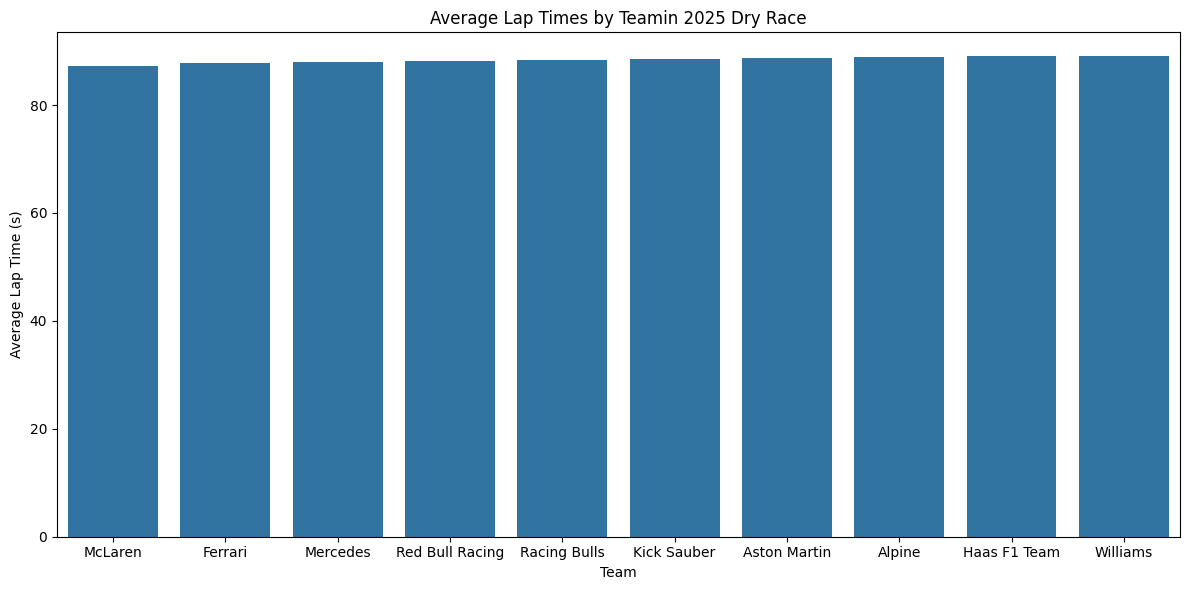

In [29]:

team_lap_times = race_2025.groupby('Team')['LapTime'].mean().reset_index()

team_lap_times = team_lap_times.sort_values(by='LapTime')

plt.figure(figsize=(12, 6))
sns.barplot(x='Team', y='LapTime', data=team_lap_times)
plt.title('Average Lap Times by Teamin 2025 Dry Race')
plt.xlabel('Team')  
plt.ylabel('Average Lap Time (s)')

plt.tight_layout()
plt.show()

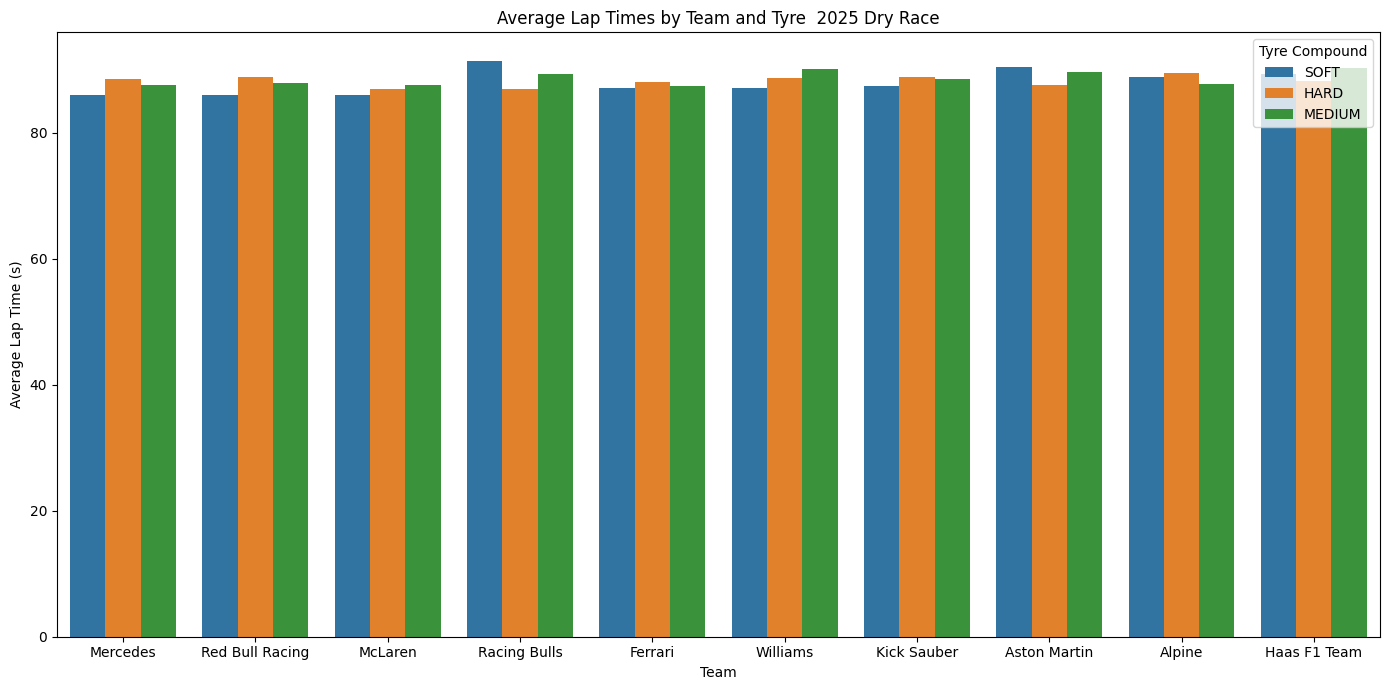

In [28]:
compound_lap_times = race_2025.groupby(['Team', 'Compound'])['LapTime'].mean().reset_index()    
compound_lap_times = compound_lap_times.sort_values(by='LapTime')
plt.figure(figsize=(14, 7))
sns.barplot(x='Team', y='LapTime', hue='Compound', data=compound_lap_times)
plt.title('Average Lap Times by Team and Tyre  2025 Dry Race')
plt.xlabel('Team')
plt.ylabel('Average Lap Time (s)')
plt.legend(title='Tyre Compound')
plt.tight_layout()
plt.show()


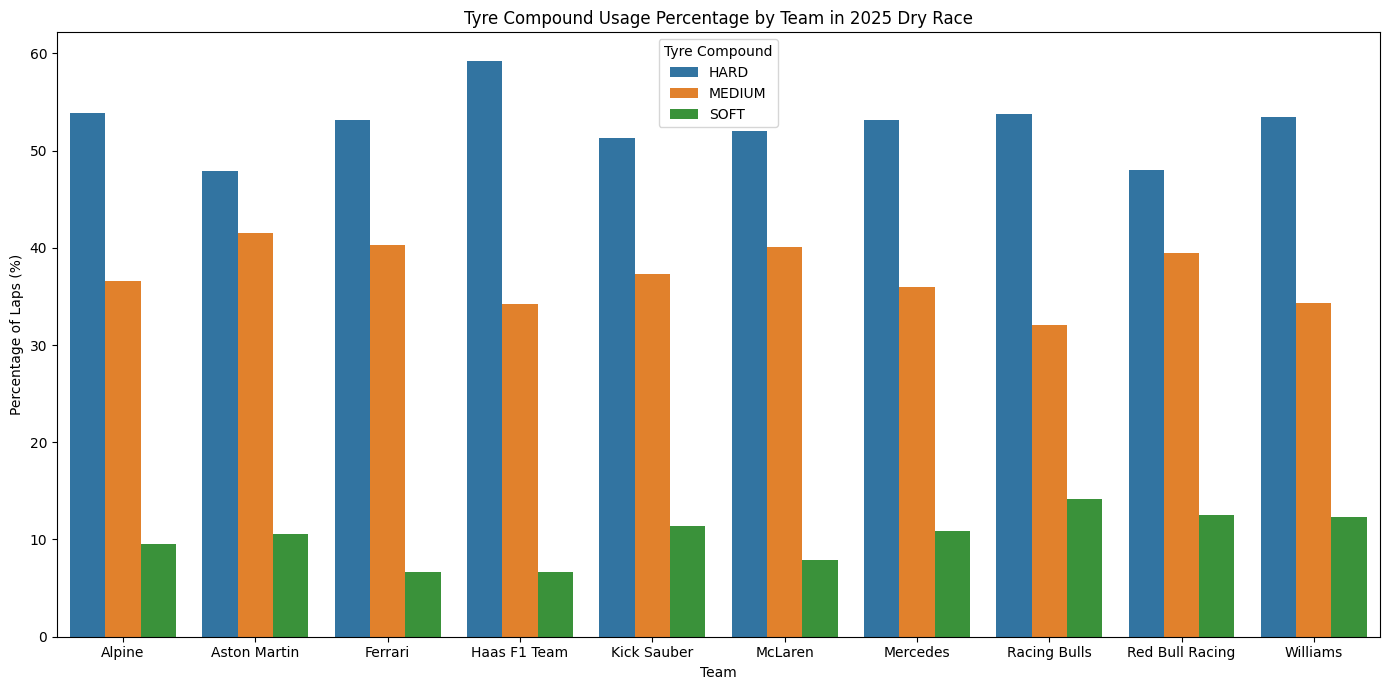

,Team,Compound,Count,TotalLaps,Percentage
0,Alpine,HARD,1992,3696,53.896104
1,Alpine,MEDIUM,1351,3696,36.553030
2,Alpine,SOFT,353,3696,9.550866
3,Aston Martin,HARD,1794,3744,47.916667
4,Aston Martin,MEDIUM,1556,3744,41.559829
5,Aston Martin,SOFT,394,3744,10.523504
6,Ferrari,HARD,2179,4101,53.133382
7,Ferrari,MEDIUM,1651,4101,40.258474
8,Ferrari,SOFT,271,4101,6.608144
9,Haas F1 Team,HARD,2311,3904,59.195697


In [30]:
#calculating what % of laps were done on each tyre compound per team
tyre_usage = race_2025.groupby(['Team', 'Compound']).size().reset_index(name='Count')
total_laps = race_2025.groupby('Team').size().reset_index(name='TotalLaps')
tyre_usage = tyre_usage.merge(total_laps, on='Team')    
tyre_usage['Percentage'] = (tyre_usage['Count'] / tyre_usage['TotalLaps']) * 100
plt.figure(figsize=(14, 7))
sns.barplot(x='Team', y='Percentage', hue='Compound', data=tyre_usage)
plt.title('Tyre Compound Usage Percentage by Team in 2025 Dry Race')
plt.xlabel('Team')
plt.ylabel('Percentage of Laps (%)')
plt.legend(title='Tyre Compound')
plt.tight_layout()
plt.show()
tyre_usage